###Deep Learning Lab Manual CAI2503, Prepared By IC: Pakruddin.B, Asst.Prof., PSCSE,PU. 2025-26

### Lab 2: Multilayer Perceptron (MLP) for MNIST Classification
# ------------------------------------------------------------
Objective: Build and train a simple fully connected network on the MNIST dataset

Duration: ~2 hours (including theory, coding, and discussion)
###What Students Will Learn
How to load and preprocess MNIST dataset.

How to build an MLP using Sequential API in Keras.

The difference between train and validation accuracy.

How to plot training curves and visualize predictions.

###Expected Outputs
Training log showing accuracy and loss over epochs.

Accuracy curve plot and loss curve plot.

Test accuracy and loss printed in console.

Visualization of a few predicted vs. actual labels.



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8408 - loss: 0.5672 - val_accuracy: 0.9551 - val_loss: 0.1555
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9588 - loss: 0.1401 - val_accuracy: 0.9653 - val_loss: 0.1200
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9741 - loss: 0.0913 - val_accuracy: 0.9678 - val_loss: 0.1056
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9784 - loss: 0.0727 - val_accuracy: 0.9713 - val_loss: 0.0972
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9856 - loss: 0.0503 - val_accuracy: 0.9731 - val_loss: 0.0901
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9869 - loss: 0.0412 - val_accuracy: 0.9755 - val_loss: 0.0942
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0329 - val_accuracy: 0.9752 - val_loss: 0.0922
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step -

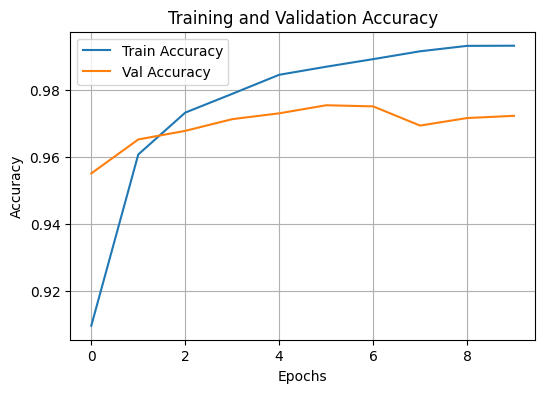

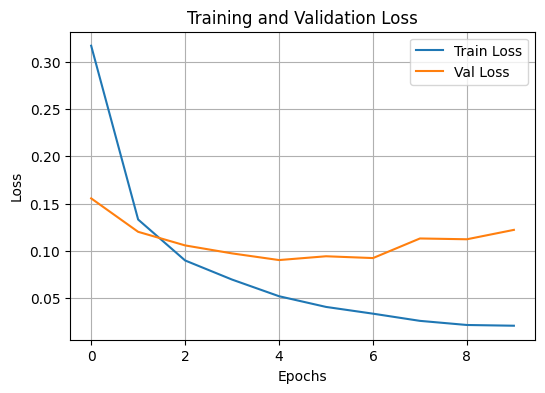

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


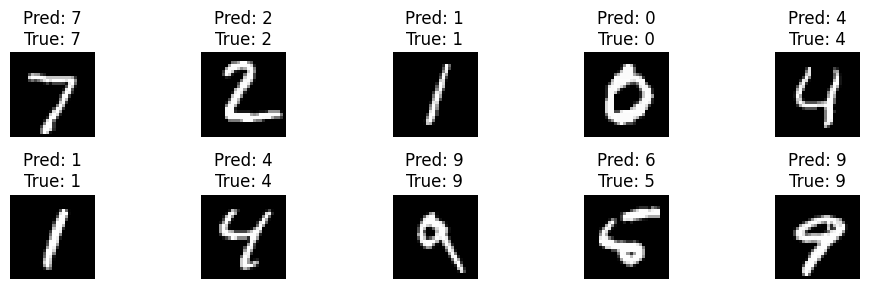

In [ ]:


import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load and preprocess MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 images into vectors of size 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 2. Define MLP model
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(x_train, y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=64,
                    verbose=1)

# 5. Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 6. Plot accuracy curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 7. Plot loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 8. Make predictions & display some results
import numpy as np

predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)

# Show first 10 test images, predicted labels, and true labels
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
